In [3]:
import rainbow as rb
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd

In [5]:
# List of all .d folders
run_folders = ["/home/prachi/Pinakin/Python/chemometric/GCMS/MSV000102547/raw/raw/A.D",
              "/home/prachi/Pinakin/Python/chemometric/GCMS/MSV000102547/raw/raw/B.D",
              "/home/prachi/Pinakin/Python/chemometric/GCMS/MSV000102547/raw/raw/C.D",
              "/home/prachi/Pinakin/Python/chemometric/GCMS/MSV000102547/raw/raw/D.D",
              "/home/prachi/Pinakin/Python/chemometric/GCMS/MSV000102547/raw/raw/E1.D",
              "/home/prachi/Pinakin/Python/chemometric/GCMS/MSV000102547/raw/raw/E2.D",
               "/home/prachi/Pinakin/Python/chemometric/GCMS/MSV000102547/raw/raw/B3-0303DJ.D"
              ]

all_features = []

for folder in run_folders:
    exp = rb.read(str(folder))
    ms_file = exp.get_file("data.ms")
    # Extract data
    x_time = ms_file.xlabels
    data_raw = ms_file.data
    mz_values = ms_file.ylabels
    
    # Calculate features
    features = {
        'file': folder.split('/')[-1],  # Just the folder name
        'num_scans': data_raw.shape[0],
        'mz_min': float(mz_values.min()),
        'mz_max': float(mz_values.max()),
        'total_ion_count': float(np.sum(data_raw)),
        'avg_intensity': float(np.mean(data_raw)),
        'max_intensity': float(np.max(data_raw)),
        'time_min': float(x_time.min()),
        'time_max': float(x_time.max()),
        'std_intensity': np.std(data_raw),
        'no of scans': len (x_time)
    }
    
    all_features.append(features)
    print(f"  ✓ Extracted features")

# Create DataFrame
df = pd.DataFrame(all_features)
print(df)

# Save to CSV
df.to_csv('gcms_features_all_6_runs.csv', index=False)
print("✓ Saved to gcms_features_all_6_runs.csv")

  ✓ Extracted features
  ✓ Extracted features
  ✓ Extracted features
  ✓ Extracted features
  ✓ Extracted features
  ✓ Extracted features
  ✓ Extracted features
          file  num_scans  mz_min  mz_max  total_ion_count  avg_intensity  \
0          A.D       5226    50.0   550.0     1.148943e+10    4388.251067   
1          B.D       5226    50.0   550.0     1.284298e+10    4905.220755   
2          C.D       5226    50.0   550.0     1.101490e+10    4207.010227   
3          D.D       5226    50.0   550.0     1.237321e+10    4725.798362   
4         E1.D       5226    50.0   550.0     1.334942e+10    5098.651859   
5         E2.D       5226    50.0   550.0     1.278266e+10    4882.184163   
6  B3-0303DJ.D       5226    50.0   550.0     1.116091e+10    4262.774088   

   max_intensity  time_min   time_max  std_intensity  no of scans  
0      8388096.0  5.092600  34.990267  118692.069232         5226  
1      8388096.0  5.092983  34.990650  124724.243374         5226  
2      8388096.0  

In [6]:
df


,file,num_scans,mz_min,mz_max,total_ion_count,avg_intensity,max_intensity,time_min,time_max,std_intensity,no of scans
0,A.D,5226,50.0,550.0,1.148943e+10,4388.251067,8388096.0,5.092600,34.990267,118692.069232,5226
1,B.D,5226,50.0,550.0,1.284298e+10,4905.220755,8388096.0,5.092983,34.990650,124724.243374,5226
2,C.D,5226,50.0,550.0,1.101490e+10,4207.010227,8388096.0,5.092817,34.990483,114500.192655,5226
3,D.D,5226,50.0,550.0,1.237321e+10,4725.798362,8388096.0,5.093050,34.990733,124204.197697,5226
4,E1.D,5226,50.0,550.0,1.334942e+10,5098.651859,8388096.0,5.092533,34.990200,128520.326477,5226
5,E2.D,5226,50.0,550.0,1.278266e+10,4882.184163,8388096.0,5.093017,34.990700,124880.630642,5226
6,B3-0303DJ.D,5226,50.0,550.0,1.116091e+10,4262.774088,8388096.0,5.092517,34.990200,116547.521311,5226


IndexError: index 3 is out of bounds for axis 0 with size 3

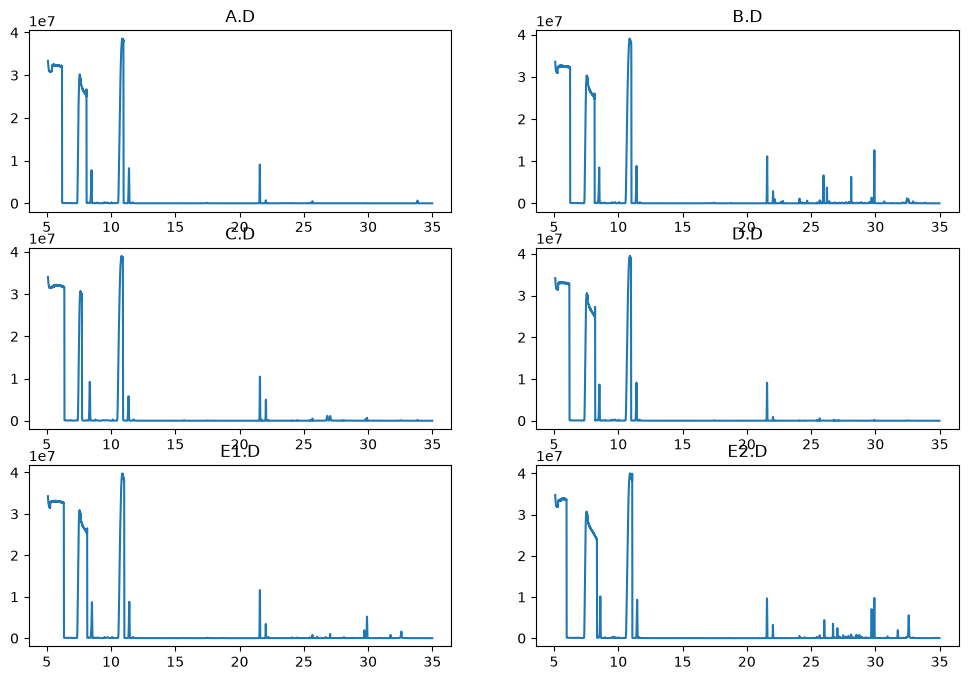

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for idx, folder in enumerate(run_folders):
    exp = rb.read(folder)
    ms_file = exp.get_file("data.ms")
    tic = np.sum(ms_file.data, axis=1)
    axes[idx//2, idx%2].plot(ms_file.xlabels, tic)
    axes[idx//2, idx%2].set_title(folder.split('/')[-1])
plt.tight_layout()
plt.savefig('tic_all_6_runs.png')
plt.show()